In [55]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torch import Tensor
import packaging
import torch.cuda.nccl as nccl
import torch.distributed as dist
from scipy import signal
import more_itertools
from typing import Optional, Tuple
from datetime import datetime
from zoneinfo import ZoneInfo
import logging
from transforms3d.axangles import axangle2mat
from transforms3d.euler import quat2euler
import pandas as pd
import numpy as np
import warnings
import math
import time
import io
import os
warnings.filterwarnings('ignore')

In [56]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

In [57]:
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    data_path = "/kaggle/input/duo-gait" # path for kaggle environment
elif os.getenv("COLAB_RELEASE_TAG"):
    from google.colab import drive
    drive.mount('drive')
    data_path = "drive/MyDrive/Colab Notebooks/Datasets" # path for google colab environment
else:
    data_path = "data" # path for local environment

In [58]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

In [59]:
class DUO_GAIT():
    def __init__(self, freq, allowed_sensors, num_participants, ignore_participant_ids, remove_imu_xyz=False, compute_jerk=True, include_norm=True, include_angle=True, include_dt=True, remove_st=False, remove_outliers=True):
        self.num_participants = num_participants
        self.allowed_sensors = allowed_sensors
        self.imu_signals = []
        self.freq = freq
        
        foot_strides_df = None
        sensor_dict = {}
        for participant_id in range(1, num_participants+1):
            if participant_id in ignore_participant_ids:
                continue

            for sensor_location in self.allowed_sensors:
                for protocol in ["control", "fatigue"]:
                    for task in ["st", "dt"]:
                        if task == "dt" and not include_dt: # skip dual task if we don't want it
                            continue

                        interim_file_name = f"{data_path}/DUO-GAIT/interim/OG_{task}_{protocol}/sub_{participant_id:02}/{sensor_location}.csv"
                        interim_sensor_df = pd.read_csv(interim_file_name)
                        interim_sensor_df.rename({ "timestamp": "Time (secs)", "Unnamed: 0": "Sample" }, axis=1, inplace=True)

                        if include_angle:
                            raw_file_name = f"{data_path}/DUO-GAIT/raw/OG_{task}_raw/sub_{participant_id:02}/{sensor_location}.csv"
                            raw_sensor_df = pd.read_csv(raw_file_name,skiprows=5).drop(index=0).astype(float)
                            raw_sensor_df = raw_sensor_df.filter(["Quat W", "Quat X", "Quat Y", "Quat Z"], axis=1)
                            raw_sensor_df.rename({ "Quat W": "QuatW", "Quat X": "QuatX", "Quat Y": "QuatY", "Quat Z": "QuatZ" },axis=1, inplace=True, errors='raise')
                            
                            quat_features_df = raw_sensor_df.loc[interim_sensor_df['Sample'].min(): interim_sensor_df['Sample'].max()].reset_index(drop=True)
                            euler_angles = quat_features_df.apply(lambda row: quat2euler(row, axes='sxyz'), axis=1)
                            euler_features_df = pd.DataFrame(euler_angles.tolist(), index=euler_angles.index, columns=['EulerX', 'EulerY', 'EulerZ']).reset_index(drop=True) # get euler angles

                            interim_sensor_df = pd.merge(interim_sensor_df, euler_features_df, left_index=True, right_index=True, how='inner')

                        sensor_dict[interim_file_name] = interim_sensor_df
            # save interim files for future

            for protocol in ["control", "fatigue"]:
                for foot in ["left", "right"]:
                    for task in ["st", "dt"]:
                        if task == "dt" and not include_dt: # skip dual task if we don't want it
                            continue

                        foot_df = pd.read_csv(f"{data_path}/DUO-GAIT/processed/OG_{task}_{protocol}/sub_{participant_id:02}/{foot}_foot_core_params.csv")
                        foot_df.rename({ "timestamps": "start_times" }, axis=1, inplace=True)
                        foot_df['is_fatigue'] = int(protocol == "fatigue")
                        foot_df['is_dual_task'] = int(task == "dt")
                        foot_df['Participant'] = participant_id

                        is_control = (protocol == "control")
                        is_dual_task = (task == "dt")
                        
                        self.create_start_end_samples_strides(sensor_dict, foot_df, participant_id, is_control=is_control, is_dual_task=is_dual_task)
                        foot_strides_df = pd.concat([foot_strides_df, foot_df], axis=0)

        if remove_outliers:
            foot_strides_df = foot_strides_df[foot_strides_df['is_outlier']==False].reset_index(drop=True)

        if remove_st:
            foot_strides_df = foot_strides_df[foot_strides_df['is_dual_task']==True].reset_index(drop=True)

        for _, row in foot_strides_df.iterrows():
            imu_signals_df_list = []
            for sensor_location in self.allowed_sensors:
                protocol = "fatigue" if row['is_fatigue'] else "control"
                task = "dt" if row['is_dual_task'] else "st"
                file_name = f"{data_path}/DUO-GAIT/interim/OG_{task}_{protocol}/sub_{row['Participant']:02}/{sensor_location}.csv"

                sensor_df = sensor_dict[file_name]
                sensor_df = sensor_df[(sensor_df['Sample'] >= row['start_samples']) & (sensor_df['Sample'] <= row['end_samples'])]

                acc_columns = ["AccX", "AccY", "AccZ"]
                gyr_columns = ["GyrX", "GyrY", "GyrZ"]
                angle_columns = ["EulerX", "EulerY", "EulerZ"] if include_angle else []

                acc_cols_pref = [f"{sensor_location}_{c}" for c in acc_columns]
                gyr_cols_pref = [f"{sensor_location}_{c}" for c in gyr_columns]

                sensor_signals_df = sensor_df[acc_columns + gyr_columns + angle_columns].reset_index(drop=True)
                sensor_signals_df = sensor_signals_df.add_prefix(f"{sensor_location}_")

                if compute_jerk:
                    acc_gyro_df = sensor_df[acc_columns + gyr_columns]
                    acc_gyro_np = acc_gyro_df.to_numpy().transpose().astype(np.float32)
                    jerk_np = np.gradient(acc_gyro_np, 1.0 / self.freq, axis=1).transpose()
                    jerk_df = pd.DataFrame(data=jerk_np, columns=["Jerk" + col for col in (acc_columns + gyr_columns)])
                    jerk_df = jerk_df.add_prefix(f"{sensor_location}_")
                    sensor_signals_df = pd.concat([sensor_signals_df, jerk_df], axis=1)

                if include_norm:
                    sensor_signals_df[f"{sensor_location}_AccM"] = np.linalg.norm(
                        sensor_signals_df[acc_cols_pref].to_numpy(), axis=1
                    )
                    sensor_signals_df[f"{sensor_location}_GyrM"] = np.linalg.norm(
                        sensor_signals_df[gyr_cols_pref].to_numpy(), axis=1
                    )

                if remove_imu_xyz:
                    sensor_signals_df.drop(columns=acc_cols_pref + gyr_cols_pref, inplace=True)

                imu_signals_df_list.append(sensor_signals_df)

            imu_signals_df = pd.concat(imu_signals_df_list, axis=1)
            imu_signals_np = imu_signals_df.to_numpy().transpose().astype(np.float32)
            
            self.imu_signals.append(imu_signals_np)
        
        self.foot_strides_df = foot_strides_df
        self.num_channels = self.imu_signals[0].shape[0]

    def create_start_end_samples_strides(self, sensor_dict, df, participant_id, is_control, is_dual_task):
        df.sort_values(by='stride_index', inplace=True)
        df['start_samples'] = df['ic_samples'].shift(1)
        target_time = df.loc[0, 'start_times']
        
        protocol = "control" if is_control else "fatigue"
        task = "dt" if is_dual_task else "st"

        file_name = f"{data_path}/DUO-GAIT/interim/OG_{task}_{protocol}/sub_{participant_id:02}/{self.allowed_sensors[0]}.csv"        
        fatigue_df = sensor_dict[file_name].copy() # copy to avoid changing sensor dict's dataframes
        fatigue_df['Delta (secs)'] = fatigue_df['Time (secs)'] - fatigue_df['Time (secs)'].min() # delta time

        ts_eq_check = fatigue_df['Delta (secs)'].apply(lambda x: math.isclose(x, target_time, rel_tol=1e-5))
        start_sample = fatigue_df[ts_eq_check]['Sample'].item() - fatigue_df['Sample'].min()

        df.loc[0, 'start_samples'] = start_sample
        df['start_samples'] = df['start_samples'] + fatigue_df['Sample'].min()
        df['end_samples'] = df['ic_samples'] + fatigue_df['Sample'].min() - 1 # make it inclusive for ending samples too

        df['start_samples'] = df['start_samples'].astype(np.int64)
        df['end_samples'] = df['end_samples'].astype(np.int64)

In [60]:
compute_jerk = False
remove_imu_xyz = False
include_norm = False
include_angle = False
include_dt = True
remove_st = False

In [61]:
dataset = DUO_GAIT(128.0, ['HE', 'LF', 'LL', 'LW', 'RF', 'RL', 'RW', 'SA', 'ST'], 18, [4, 16], remove_imu_xyz, compute_jerk, include_norm, include_angle, include_dt, remove_st)

In [62]:
df = dataset.foot_strides_df.sample(frac=0.7, random_state=42) # training set
df['fatigue_label'] = df['is_fatigue'].map({0: 'Non-Fatigued', 1: 'Fatigued'})
df['dual_task_label'] = df['is_dual_task'].map({0: 'Single-Task', 1: 'Dual-Task'})

In [63]:
df

,stride_index,start_times,stride_lengths,clearances_min,clearances_max,stride_times,swing_times,stance_times,stance_ratios,fo_times,ic_times,fo_samples,ic_samples,is_outlier,turning_step,turning_interval,interrupted,is_fatigue,is_dual_task,Participant,start_samples,end_samples,fatigue_label,dual_task_label
22023,82,100.92969,1.465914,0.007763,0.071222,1.21875,0.53125,0.68750,0.564103,101.61719,102.14844,13007,13075,False,False,False,False,0,1,11,111919,112074,Non-Fatigued,Dual-Task
34133,16,18.25781,1.515444,0.008170,0.062471,0.99219,0.45313,0.53906,0.543303,18.79687,19.25000,2406,2464,False,False,False,False,1,0,17,252637,252763,Fatigued,Single-Task
3594,164,188.15625,1.606443,-0.008038,0.053175,1.06250,0.47656,0.58594,0.551473,188.74219,189.21875,24159,24220,False,False,False,False,1,0,2,416945,417080,Fatigued,Single-Task
12296,146,150.09375,1.365105,0.018844,0.068057,0.96875,0.42969,0.53906,0.556449,150.63281,151.06250,19281,19336,False,False,False,False,0,0,7,117712,117835,Non-Fatigued,Single-Task
22277,57,70.39844,1.475089,0.009495,0.067492,1.13281,0.49219,0.64062,0.565514,71.03906,71.53125,9093,9156,False,False,False,False,1,0,11,430411,430555,Fatigued,Single-Task
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16059,338,371.92969,1.262238,-0.000297,0.047313,1.14062,0.50000,0.64062,0.561642,372.57031,373.07031,47689,47753,False,False,False,False,1,0,8,270007,270152,Fatigued,Single-Task
18044,182,215.76562,1.381093,0.014048,0.064977,1.14063,0.44532,0.69531,0.609584,216.46093,216.90625,27707,27764,False,False,False,False,1,1,9,287968,288113,Fatigued,Dual-Task
73,77,101.56250,1.379887,0.007277,0.067619,1.16406,0.48437,0.67969,0.583896,102.24219,102.72656,13087,13149,False,False,False,False,0,0,1,62000,62148,Non-Fatigued,Single-Task
1843,177,221.71875,1.348571,0.006051,0.063369,1.17188,0.46094,0.71094,0.606666,222.42969,222.89063,28471,28530,False,False,False,False,1,0,1,351280,351429,Fatigued,Single-Task


In [ ]:
sns.set_theme(style="whitegrid")

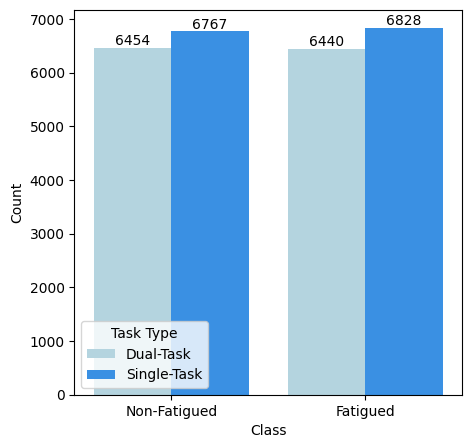

In [96]:
plt.subplots(figsize=(5, 5))

palette = ["#ADD8E6", "#1E90FF"]
ax = sns.countplot(data=df, x='fatigue_label', hue='dual_task_label', palette=palette, order=['Non-Fatigued', 'Fatigued'])

# plt.title('Class Distribution of Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.legend(title='Task Type',fontsize=10, title_fontsize=10)

for container in ax.containers:
    ax.bar_label(container)

plt.show()